In [7]:
import os
# Ẩn các cảnh báo hệ thống của TensorFlow (0=ALL, 1=INFO, 2=WARNING, 3=ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import tensorflow as tf
tf.get_logger().setLevel('ERROR') # Ẩn các cảnh báo Python của TensorFlow

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from tensorflow.keras.models import load_model
import json

# Định nghĩa các bộ dữ liệu và mô hình 1D-CNN tương ứng
ablation_configs = {
    "Hands Only": {
        "data_dir": "../data/hands/",
        "model_path": "../models/cnn1d_model_hand.h5"
    },
    "Pose + Hands": {
        "data_dir": "../data/pose_hands/",
        "model_path": "../models/cnn1d_model_hands_pose.h5"
    },
    "Full Holistic": {
        "data_dir": "../data/holistic/",
        "model_path": "../models/cnn1d_model.h5"
    }
}

with open('../configs/labels.json', 'r', encoding='utf-8') as f:
    class_names = json.load(f)

In [8]:
results = {}

print(f"{'Feature Set':<15} | {'Accuracy':<8} | {'Macro Precision':<15} | {'Macro Recall':<12} | {'Macro F1'}")
print("-" * 75)

for config_name, paths in ablation_configs.items():
    # Load Test Data
    X_test = np.load(f"{paths['data_dir']}X_test.npy")
    y_test = np.load(f"{paths['data_dir']}y_test.npy")
    
    # Load Model & Predict
    model = load_model(paths['model_path'])
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    
    # Tính toán Metrics
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    acc = report['accuracy']
    mac_prec = report['macro avg']['precision']
    mac_rec = report['macro avg']['recall']
    mac_f1 = report['macro avg']['f1-score']
    
    print(f"{config_name:<15} | {acc:.4f}   | {mac_prec:.4f}          | {mac_rec:.4f}       | {mac_f1:.4f}")
    
    # Lưu lại kết quả dự đoán để vẽ biểu đồ ở Cell sau
    results[config_name] = {
        "y_test": y_test,
        "y_pred": y_pred,
        "accuracy": acc
    }

Feature Set     | Accuracy | Macro Precision | Macro Recall | Macro F1
---------------------------------------------------------------------------
Hands Only      | 0.8957   | 0.9120          | 0.8937       | 0.8935
Pose + Hands    | 0.9147   | 0.9273          | 0.9115       | 0.9093
Full Holistic   | 0.8673   | 0.8769          | 0.8581       | 0.8598


In [10]:
# Đảm bảo thư mục results tồn tại
os.makedirs('../results', exist_ok=True)

# Duyệt qua từng cấu hình Ablation
for name, config in ablation_configs.items():
    print(f"Đang xử lý xuất báo cáo cho: {name}...")
    
    # 1. Load dữ liệu test và model
    X_test = np.load(config["data_dir"] + 'X_test.npy')
    y_test = np.load(config["data_dir"] + 'y_test.npy')
    model = load_model(config["model_path"])
    
    # 2. Chạy dự đoán
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    
    # 3. Tính toán các chỉ số tổng quát
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    
    # Lấy bảng report chi tiết (chỉnh digits=4 để lấy 4 số thập phân giống hình)
    report_text = classification_report(y_test, y_pred, digits=4, zero_division=0)
    
    # 4. Đặt tên file tự động dựa theo tên cấu hình
    safe_name = name.lower().replace(" + ", "_").replace(" ", "_")
    file_path = f"../results/cnn1d_metrics_{safe_name}.txt"
    
    # 5. Ghi dữ liệu ra file text
    with open(file_path, 'w', encoding='utf-8') as f:
        f.write(f"Accuracy: {acc:.4f}\n")
        f.write(f"Macro Precision: {precision:.4f}\n")
        f.write(f"Macro Recall: {recall:.4f}\n")
        f.write(f"Macro F1-score: {f1:.4f}\n\n")
        f.write(report_text)
        
    print(f"-> Đã xuất thành công: {file_path}\n")

Đang xử lý xuất báo cáo cho: Hands Only...
-> Đã xuất thành công: ../results/cnn1d_metrics_hands_only.txt

Đang xử lý xuất báo cáo cho: Pose + Hands...
-> Đã xuất thành công: ../results/cnn1d_metrics_pose_hands.txt

Đang xử lý xuất báo cáo cho: Full Holistic...
-> Đã xuất thành công: ../results/cnn1d_metrics_full_holistic.txt



In [11]:
# Cấu hình đường dẫn cho các model LSTM
lstm_configs = {
    "Hands Only": {
        "data_dir": "../data/hands/",
        "model_path": "../models/lstm_model_hand.h5"
    },
    "Pose + Hands": {
        "data_dir": "../data/pose_hands/",
        "model_path": "../models/lstm_model_hands_pose.h5"
    },
    "Full Holistic": {
        "data_dir": "../data/holistic/",
        "model_path": "../models/lstm_model.h5"
    }
}

os.makedirs('../results', exist_ok=True)

for name, config in lstm_configs.items():
    print(f"Đang xử lý xuất báo cáo LSTM cho: {name}...")
    
    X_test = np.load(config["data_dir"] + 'X_test.npy')
    y_test = np.load(config["data_dir"] + 'y_test.npy')
    model = load_model(config["model_path"])
    
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    report_text = classification_report(y_test, y_pred, digits=4, zero_division=0)
    
    safe_name = name.lower().replace(" + ", "_").replace(" ", "_")
    file_path = f"../results/lstm_metrics_{safe_name}.txt"
    
    with open(file_path, 'w', encoding='utf-8') as f:
        f.write(f"Accuracy: {acc:.4f}\n")
        f.write(f"Macro Precision: {precision:.4f}\n")
        f.write(f"Macro Recall: {recall:.4f}\n")
        f.write(f"Macro F1-score: {f1:.4f}\n\n")
        f.write(report_text)
        
    print(f"-> Đã xuất thành công: {file_path}\n")

Đang xử lý xuất báo cáo LSTM cho: Hands Only...
-> Đã xuất thành công: ../results/lstm_metrics_hands_only.txt

Đang xử lý xuất báo cáo LSTM cho: Pose + Hands...
-> Đã xuất thành công: ../results/lstm_metrics_pose_hands.txt

Đang xử lý xuất báo cáo LSTM cho: Full Holistic...
-> Đã xuất thành công: ../results/lstm_metrics_full_holistic.txt



In [12]:
# Cấu hình đường dẫn cho các model BiLSTM
bilstm_configs = {
    "Hands Only": {
        "data_dir": "../data/hands/",
        "model_path": "../models/bilstm_model_hand.h5"
    },
    "Pose + Hands": {
        "data_dir": "../data/pose_hands/",
        "model_path": "../models/bilstm_model_hands_pose.h5"
    },
    "Full Holistic": {
        "data_dir": "../data/holistic/",
        "model_path": "../models/bilstm_model.h5"
    }
}

os.makedirs('../results', exist_ok=True)

for name, config in bilstm_configs.items():
    print(f"Đang xử lý xuất báo cáo BiLSTM cho: {name}...")
    
    X_test = np.load(config["data_dir"] + 'X_test.npy')
    y_test = np.load(config["data_dir"] + 'y_test.npy')
    model = load_model(config["model_path"])
    
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    report_text = classification_report(y_test, y_pred, digits=4, zero_division=0)
    
    safe_name = name.lower().replace(" + ", "_").replace(" ", "_")
    file_path = f"../results/bilstm_metrics_{safe_name}.txt"
    
    with open(file_path, 'w', encoding='utf-8') as f:
        f.write(f"Accuracy: {acc:.4f}\n")
        f.write(f"Macro Precision: {precision:.4f}\n")
        f.write(f"Macro Recall: {recall:.4f}\n")
        f.write(f"Macro F1-score: {f1:.4f}\n\n")
        f.write(report_text)
        
    print(f"-> Đã xuất thành công: {file_path}\n")

Đang xử lý xuất báo cáo BiLSTM cho: Hands Only...
-> Đã xuất thành công: ../results/bilstm_metrics_hands_only.txt

Đang xử lý xuất báo cáo BiLSTM cho: Pose + Hands...
-> Đã xuất thành công: ../results/bilstm_metrics_pose_hands.txt

Đang xử lý xuất báo cáo BiLSTM cho: Full Holistic...
-> Đã xuất thành công: ../results/bilstm_metrics_full_holistic.txt



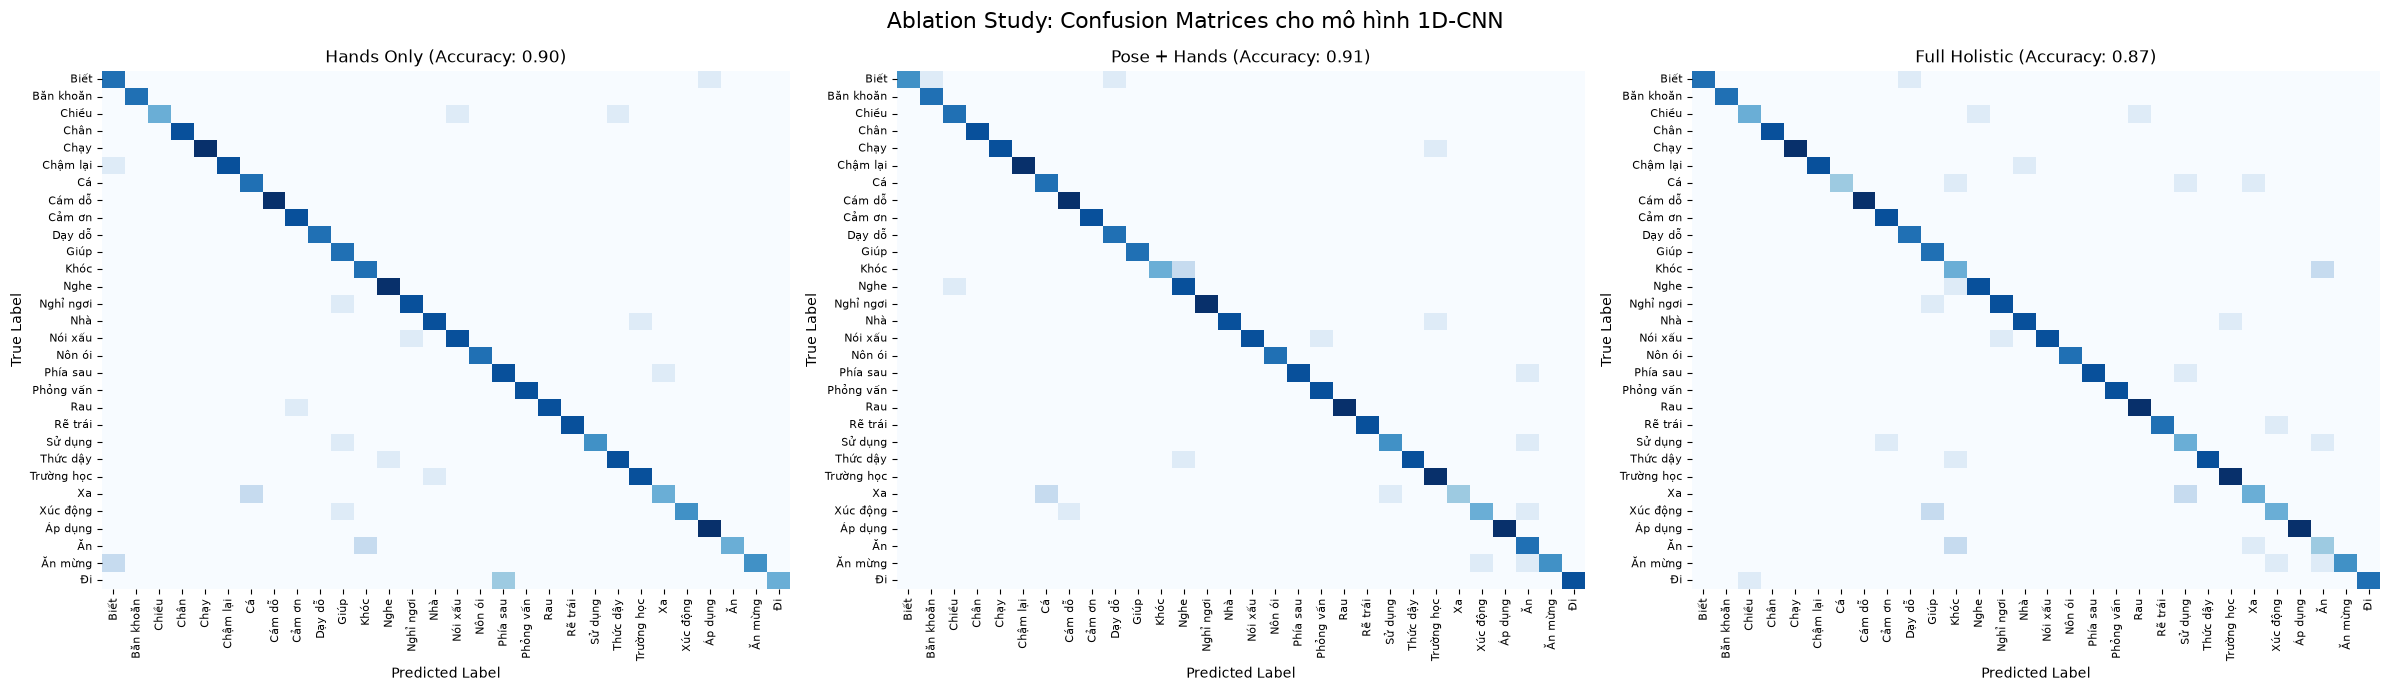

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Ablation Study: Confusion Matrices cho mô hình 1D-CNN', fontsize=16)

for idx, (config_name, data) in enumerate(results.items()):
    cm = confusion_matrix(data["y_test"], data["y_pred"])
    
    # Vẽ Heatmap (có thể đổi annot=True nếu muốn hiện số trong ô)
    sns.heatmap(cm, annot=False, cmap='Blues', ax=axes[idx], cbar=False)
    
    # Chèn nhãn trục
    axes[idx].set_xticks(np.arange(len(class_names)) + 0.5)
    axes[idx].set_xticklabels(class_names, rotation=90, ha="center", fontsize=8)
    axes[idx].set_yticks(np.arange(len(class_names)) + 0.5)
    axes[idx].set_yticklabels(class_names, rotation=0, fontsize=8)
    
    axes[idx].set_title(f"{config_name} (Accuracy: {data['accuracy']:.2f})")
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()

# ĐÃ THÊM: Lưu biểu đồ thành file ảnh PNG với chất lượng 300 DPI
plt.savefig('../results/cnn1d_confusion_matrices.png', dpi=300, bbox_inches='tight')

plt.show()

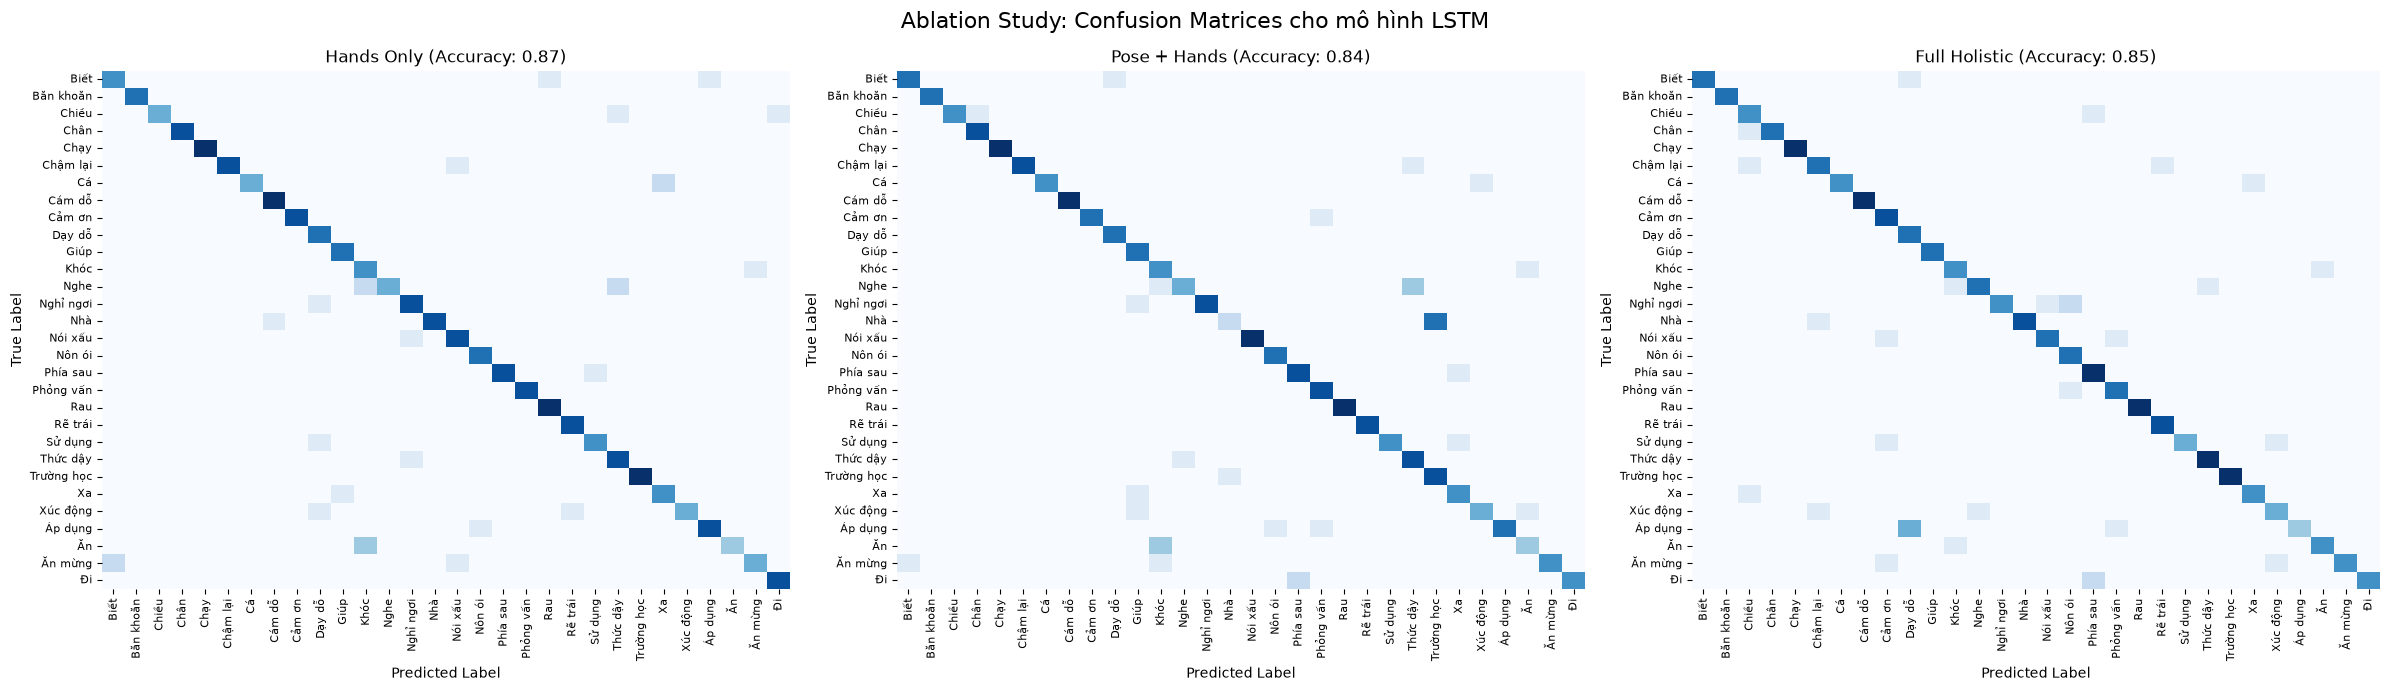

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Ablation Study: Confusion Matrices cho mô hình LSTM', fontsize=16)

for idx, (config_name, config) in enumerate(lstm_configs.items()):
    # Load data và model
    X_test = np.load(config["data_dir"] + 'X_test.npy')
    y_test = np.load(config["data_dir"] + 'y_test.npy')
    model = load_model(config["model_path"])
    
    # Dự đoán và tính accuracy
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    # Vẽ Heatmap
    sns.heatmap(cm, annot=False, cmap='Blues', ax=axes[idx], cbar=False)
    
    # Chèn nhãn trục
    axes[idx].set_xticks(np.arange(len(class_names)) + 0.5)
    axes[idx].set_xticklabels(class_names, rotation=90, ha="center", fontsize=8)
    axes[idx].set_yticks(np.arange(len(class_names)) + 0.5)
    axes[idx].set_yticklabels(class_names, rotation=0, fontsize=8)
    
    axes[idx].set_title(f"{config_name} (Accuracy: {acc:.2f})")
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.savefig('../results/lstm_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

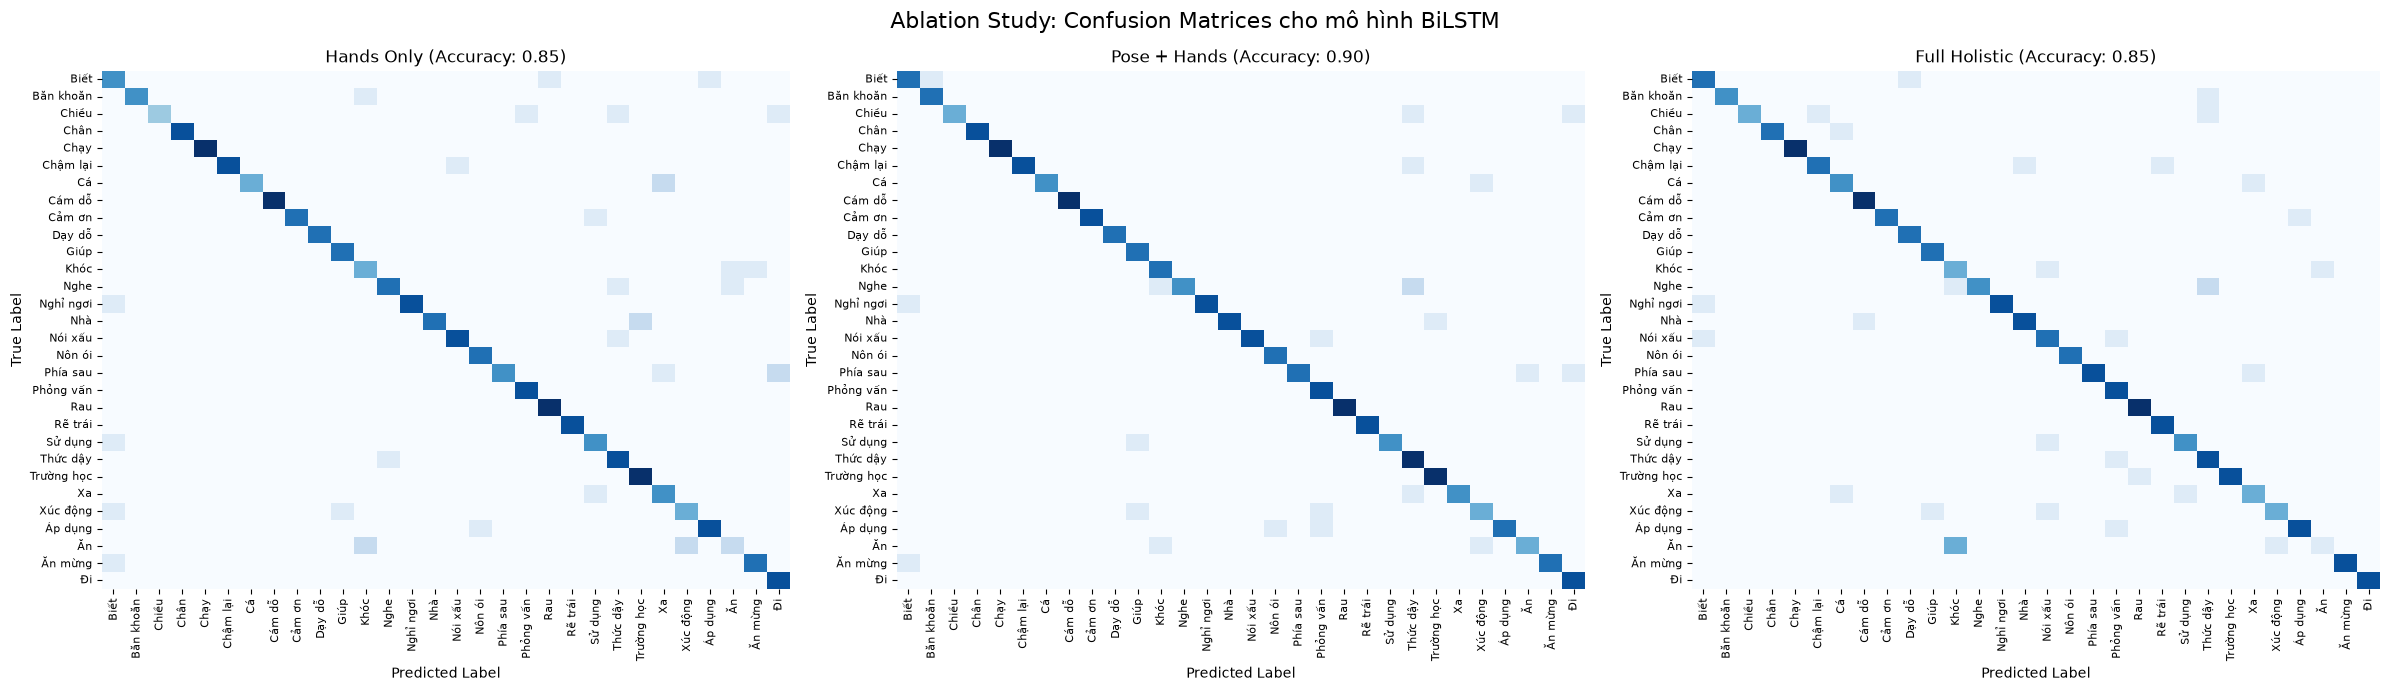

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Ablation Study: Confusion Matrices cho mô hình BiLSTM', fontsize=16)

for idx, (config_name, config) in enumerate(bilstm_configs.items()):
    # Load data và model
    X_test = np.load(config["data_dir"] + 'X_test.npy')
    y_test = np.load(config["data_dir"] + 'y_test.npy')
    model = load_model(config["model_path"])
    
    # Dự đoán và tính accuracy
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    # Vẽ Heatmap
    sns.heatmap(cm, annot=False, cmap='Blues', ax=axes[idx], cbar=False)
    
    # Chèn nhãn trục
    axes[idx].set_xticks(np.arange(len(class_names)) + 0.5)
    axes[idx].set_xticklabels(class_names, rotation=90, ha="center", fontsize=8)
    axes[idx].set_yticks(np.arange(len(class_names)) + 0.5)
    axes[idx].set_yticklabels(class_names, rotation=0, fontsize=8)
    
    axes[idx].set_title(f"{config_name} (Accuracy: {acc:.2f})")
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.savefig('../results/bilstm_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()